In [13]:
# ============================================================
# 1. LOAD EXPERIMENT ASSIGNMENTS
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent

OUTPUT_TABLE_PATH = PROJECT_ROOT / "outputs" / "tables"
OUTPUT_FIGURE_PATH = PROJECT_ROOT / "outputs" / "figures"

experiment_path = (
    OUTPUT_TABLE_PATH / "experiment_assignments.csv"
)

experiment = pd.read_csv(experiment_path)

print("Experiment customers:", len(experiment))
print("\nColumns:")
print(experiment.columns.tolist())

print("\nExperiment groups:")
print(
    experiment["experiment_group"]
    .value_counts()
)

print("\nEligible customers:")
print(
    experiment["eligible_for_intervention"]
    .value_counts()
)

Experiment customers: 4661

Columns:
['customer_id', 'customer_segment_x', 'total_sessions', 'peak_sessions', 'peak_share', 'total_energy_kwh', 'avg_energy_kwh', 'flexibility_score', 'eligible_for_intervention', 'intervention_score', 'priority_band', 'city', 'experiment_group', 'incentive_rate', 'intervention', 'base_response_probability', 'response_probability', 'responded', 'shifted_peak_sessions', 'post_peak_sessions', 'demand_shift_rate']

Experiment groups:
experiment_group
Treatment    2357
Control      2304
Name: count, dtype: int64

Eligible customers:
eligible_for_intervention
True    4661
Name: count, dtype: int64


In [14]:
# ============================================================
# 2. SIMULATE POST-INTERVENTION CUSTOMER RESPONSE
# ============================================================

np.random.seed(42)

# Normalize flexibility to 0–1
flex_min = experiment["flexibility_score"].min()
flex_max = experiment["flexibility_score"].max()

experiment["flexibility_norm"] = (
    (experiment["flexibility_score"] - flex_min)
    / (flex_max - flex_min)
)

# Baseline probability of responding
# More flexible customers are more likely to shift.
control_probability = (
    0.05
    + 0.30 * experiment["flexibility_norm"]
)

# Treatment receives the targeted off-peak incentive.
# Treatment gets an incremental response lift.
treatment_probability = (
    control_probability + 0.10
)

# Keep probabilities within realistic bounds.
treatment_probability = treatment_probability.clip(
    upper=0.90
)

experiment["response_probability"] = np.where(
    experiment["experiment_group"] == "Treatment",
    treatment_probability,
    control_probability
)

# Simulate whether customer responds.
experiment["responded"] = (
    np.random.random(len(experiment))
    < experiment["response_probability"]
).astype(int)

print("Responses:")
print(
    experiment.groupby("experiment_group")["responded"]
    .agg(["count", "sum", "mean"])
)

Responses:
                  count  sum      mean
experiment_group                      
Control            2304  446  0.193576
Treatment          2357  678  0.287654


In [15]:
# ============================================================
# 3. ESTIMATE SHIFTED PEAK SESSIONS
# ============================================================

experiment["shifted_peak_sessions"] = (
    experiment["peak_sessions"]
    * experiment["responded"]
    * experiment["flexibility_norm"]
)

experiment["shifted_peak_sessions"] = (
    experiment["shifted_peak_sessions"]
    .round()
    .astype(int)
)

print(
    experiment[
        [
            "experiment_group",
            "peak_sessions",
            "responded",
            "shifted_peak_sessions"
        ]
    ].head(10)
)

  experiment_group  peak_sessions  responded  shifted_peak_sessions
0          Control            172          0                      0
1        Treatment            201          0                      0
2          Control            161          0                      0
3          Control            159          0                      0
4        Treatment            201          1                    100
5          Control            148          1                    110
6          Control            155          1                     91
7          Control            179          0                      0
8        Treatment            162          0                      0
9        Treatment            151          0                      0


In [16]:
# ============================================================
# 4. PRIMARY EXPERIMENT METRIC
# ============================================================

group_results = (
    experiment
    .groupby("experiment_group")
    .agg(
        customers=("customer_id", "count"),
        responders=("responded", "sum"),
        peak_sessions=("peak_sessions", "sum"),
        shifted_peak_sessions=("shifted_peak_sessions", "sum")
    )
)

group_results["response_rate"] = (
    group_results["responders"]
    / group_results["customers"]
)

group_results["session_shift_rate"] = (
    group_results["shifted_peak_sessions"]
    / group_results["peak_sessions"]
)

print(group_results.round(4))

                  customers  responders  peak_sessions  shifted_peak_sessions  \
experiment_group                                                                
Control                2304         446         104873                  12081   
Treatment              2357         678         106972                  17316   

                  response_rate  session_shift_rate  
experiment_group                                     
Control                  0.1936              0.1152  
Treatment                0.2877              0.1619  


In [17]:
# ============================================================
# 5. TREATMENT EFFECT
# ============================================================

control_rate = group_results.loc[
    "Control",
    "response_rate"
]

treatment_rate = group_results.loc[
    "Treatment",
    "response_rate"
]

absolute_effect = (
    treatment_rate - control_rate
)

relative_effect = (
    absolute_effect / control_rate
)

print("EXPERIMENT EFFECT")
print("=" * 60)

print(f"Control response rate:   {control_rate:.2%}")
print(f"Treatment response rate: {treatment_rate:.2%}")

print(
    f"\nAbsolute treatment effect: "
    f"{absolute_effect:.2%}"
)

print(
    f"Relative treatment effect: "
    f"{relative_effect:.2%}"
)

EXPERIMENT EFFECT
Control response rate:   19.36%
Treatment response rate: 28.77%

Absolute treatment effect: 9.41%
Relative treatment effect: 48.60%


In [18]:
# ============================================================
# 6. TWO-PROPORTION TEST
# ============================================================

from scipy.stats import chi2_contingency

treatment_responders = group_results.loc[
    "Treatment", "responders"
]

treatment_nonresponders = (
    group_results.loc["Treatment", "customers"]
    - treatment_responders
)

control_responders = group_results.loc[
    "Control", "responders"
]

control_nonresponders = (
    group_results.loc["Control", "customers"]
    - control_responders
)

contingency_table = np.array([
    [
        treatment_responders,
        treatment_nonresponders
    ],
    [
        control_responders,
        control_nonresponders
    ]
])

chi2, p_value, dof, expected = chi2_contingency(
    contingency_table
)

print("TWO-PROPORTION TEST")
print("=" * 60)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value:              {p_value:.6f}")

if p_value < 0.05:
    print("\nResult: Statistically significant")
else:
    print("\nResult: Not statistically significant")

TWO-PROPORTION TEST
Chi-square statistic: 55.8366
P-value:              0.000000

Result: Statistically significant


In [21]:
# ============================================================
# 7. 95% CONFIDENCE INTERVAL
# ============================================================

# Recreate treatment/control counts directly from group_results
treatment_successes = group_results.loc["Treatment", "responders"]
control_successes = group_results.loc["Control", "responders"]

treatment_n = group_results.loc["Treatment", "customers"]
control_n = group_results.loc["Control", "customers"]

# Proportions
p_treatment = treatment_successes / treatment_n
p_control = control_successes / control_n

# Difference in proportions
absolute_effect = p_treatment - p_control

# Standard error
standard_error = np.sqrt(
    (p_treatment * (1 - p_treatment) / treatment_n)
    +
    (p_control * (1 - p_control) / control_n)
)

# 95% confidence interval
z_critical = 1.96

ci_low = absolute_effect - z_critical * standard_error
ci_high = absolute_effect + z_critical * standard_error

print("TREATMENT EFFECT WITH 95% CI")
print("=" * 60)

print(f"Treatment response rate: {p_treatment:.2%}")
print(f"Control response rate:   {p_control:.2%}")
print(f"Estimated effect:         {absolute_effect:.2%}")
print(f"95% CI:                   {ci_low:.2%} to {ci_high:.2%}")

TREATMENT EFFECT WITH 95% CI
Treatment response rate: 28.77%
Control response rate:   19.36%
Estimated effect:         9.41%
95% CI:                   6.97% to 11.85%


In [22]:
# ============================================================
# 8. SEGMENT-LEVEL TREATMENT EFFECT
# ============================================================

segment_results = (
    experiment
    .groupby(
        [
            "customer_segment_x",
            "experiment_group"
        ]
    )
    .agg(
        customers=("customer_id", "count"),
        responders=("responded", "sum"),
        peak_sessions=("peak_sessions", "sum"),
        shifted_peak_sessions=("shifted_peak_sessions", "sum")
    )
    .reset_index()
)

segment_results["response_rate"] = (
    segment_results["responders"]
    / segment_results["customers"]
)

segment_results["session_shift_rate"] = (
    segment_results["shifted_peak_sessions"]
    / segment_results["peak_sessions"]
)

print(
    segment_results.round(4)
)

  customer_segment_x experiment_group  customers  responders  peak_sessions  \
0  Convenience_First          Control        585          92          16070   
1  Convenience_First        Treatment        601         145          16387   
2       High_Mileage          Control        229          63          28114   
3       High_Mileage        Treatment        233          81          28728   
4    Price_Sensitive          Control        504         106          16644   
5    Price_Sensitive        Treatment        468         145          15298   
6   Routine_Commuter          Control        986         185          44045   
7   Routine_Commuter        Treatment       1055         307          46559   

   shifted_peak_sessions  response_rate  session_shift_rate  
0                   1047         0.1573              0.0652  
1                   1524         0.2413              0.0930  
2                   5260         0.2751              0.1871  
3                   6923         0.3476 

In [23]:
# ============================================================
# 9. COMPARE TREATMENT VS CONTROL BY SEGMENT
# ============================================================

segment_pivot = segment_results.pivot(
    index="customer_segment_x",
    columns="experiment_group",
    values="response_rate"
)

segment_pivot["treatment_effect"] = (
    segment_pivot["Treatment"]
    - segment_pivot["Control"]
)

segment_pivot = (
    segment_pivot
    .sort_values(
        "treatment_effect",
        ascending=False
    )
)

print("\nSEGMENT TREATMENT EFFECT")
print("=" * 60)

print(
    segment_pivot.round(4)
)


SEGMENT TREATMENT EFFECT
experiment_group    Control  Treatment  treatment_effect
customer_segment_x                                      
Routine_Commuter     0.1876     0.2910            0.1034
Price_Sensitive      0.2103     0.3098            0.0995
Convenience_First    0.1573     0.2413            0.0840
High_Mileage         0.2751     0.3476            0.0725


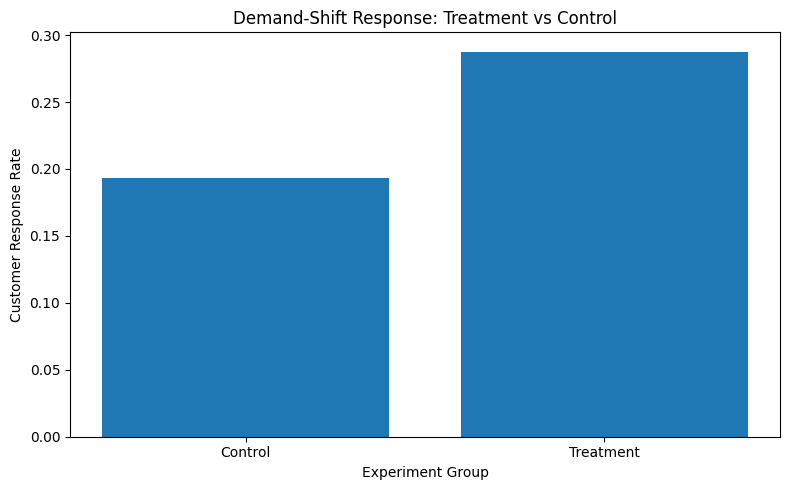

In [24]:
# ============================================================
# 10. TREATMENT VS CONTROL
# ============================================================

plot_data = group_results["response_rate"]

plt.figure(figsize=(8, 5))

plt.bar(
    plot_data.index,
    plot_data.values
)

plt.title(
    "Demand-Shift Response: Treatment vs Control"
)

plt.xlabel("Experiment Group")
plt.ylabel("Customer Response Rate")

plt.tight_layout()

plt.savefig(
    OUTPUT_FIGURE_PATH
    / "treatment_vs_control_response.png",
    dpi=150
)

plt.show()

In [25]:
# ============================================================
# 11. SAVE EXPERIMENT ANALYSIS
# ============================================================

group_results.to_csv(
    OUTPUT_TABLE_PATH
    / "experiment_group_results.csv"
)

segment_results.to_csv(
    OUTPUT_TABLE_PATH
    / "experiment_segment_results.csv",
    index=False
)

experiment.to_csv(
    OUTPUT_TABLE_PATH
    / "experiment_customer_outcomes.csv",
    index=False
)

print("Experiment analysis outputs saved.")

Experiment analysis outputs saved.
